# Basic Analysis

## Getting Started

### Needed Libraries

In [1]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import polars as pl
from great_tables import GT, md, html
from great_tables.data import islands
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

Changing the directory so I don't have to hard code long paths

In [2]:
print(f'Current: {os.getcwd()}')
os.chdir('/Users/camsmithers/Desktop/Camalytics/CamalyticsEnv/Projects/Sports/NFL/Data/Datasets/finished')
print(f'Current: {os.getcwd()}')

Current: /Users/camsmithers/Desktop/Camalytics/CamalyticsEnv/Projects/Sports/NFL/Analysis
Current: /Users/camsmithers/Desktop/Camalytics/CamalyticsEnv/Projects/Sports/NFL/Data/Datasets/finished


### Loading in Data

In [3]:
stats_team = pd.read_csv('full_team_stats.csv', index_col=0)
stats_rush = pd.read_csv('full_rushing.csv', index_col=0)
stats_rec = pd.read_csv('full_receiving.csv', index_col=0)
stats_pass = pd.read_csv('full_passing.csv', index_col=0)

### Running Summary Statistics

#### Team Stats

In [4]:
stats_team.describe().round(1)

,first_downs,net_pass_yards,total_yards,turnovers,score,opp_score,attempts,yards,touchdowns,interceptions,...,successrate4thdown_avg,successrate3rddown_avg,possessiontime_avg,yards_per_penalty_avg,penalties_avg,gameplayed_total,outcome_total,win_pct,possession_pct,possession_pct_avg
count,2278.0,2278.0,2278.0,2278.0,2278.0,2278.0,2278.0,2278.0,2278.0,2278.0,...,2278.0,2278.0,2278.0,2278.0,2278.0,2278.0,2278.0,2278.0,2278.0,2278.0
mean,19.8,221.5,338.8,1.3,22.5,22.5,33.6,237.8,1.5,0.8,...,29.6,27.4,1812.8,8.3,5.9,17.9,9.1,49.9,50.4,50.4
std,4.9,74.7,83.2,1.2,9.9,9.9,8.2,72.4,1.1,0.9,...,6.1,2.7,78.4,0.6,0.8,1.1,3.7,17.7,7.5,2.2
min,4.0,-9.0,47.0,0.0,0.0,0.0,3.0,7.0,0.0,0.0,...,15.0,19.4,1535.4,7.1,4.0,17.0,2.0,11.8,29.5,42.7
25%,16.0,171.0,282.0,0.0,16.0,16.0,28.0,188.0,1.0,0.0,...,25.9,25.7,1765.2,7.8,5.3,17.0,7.0,41.2,44.9,49.0
50%,20.0,217.0,338.0,1.0,22.0,22.0,33.0,234.0,1.0,1.0,...,29.5,27.3,1814.1,8.2,5.8,17.0,9.0,52.6,50.4,50.4
75%,23.0,269.8,394.8,2.0,29.0,29.0,39.0,283.0,2.0,1.0,...,33.3,29.1,1865.4,8.7,6.5,18.0,11.0,61.1,55.7,51.8
max,38.0,498.0,726.0,6.0,70.0,70.0,68.0,525.0,6.0,5.0,...,43.7,33.5,2003.9,10.4,8.1,21.0,18.0,85.7,76.8,55.7


#### Rushing Statistics

In [5]:
stats_rush.describe().round(1)

,rushingattempts,rushyards,rushtds,longestrush,targets,receptions,receivingyards,receivingtds,fumbles,fumbleslost,...,yardsperrush_sn_avg,firstdownsrushing,yardsbeforecontact,yardsbeforecontactper,yardsaftercontact,yardsaftercontactper,brokentackles,brokentacklesper,yardsbeforecontact_sn_avg,yardsaftercontact_sn_avg
count,2266.0,2266.0,2266.0,2266.0,2266.0,2266.0,2266.0,2266.0,2266.0,2266.0,...,2266.0,2229.0,2266.0,2266.0,2266.0,2266.0,2266.0,1216.0,2266.0,2266.0
mean,15.7,69.2,0.5,18.5,3.1,2.5,18.5,0.1,0.1,0.1,...,4.4,3.7,37.4,2.4,31.8,2.0,1.1,11.2,30.6,26.0
std,4.8,33.9,0.7,12.9,2.4,2.0,19.6,0.3,0.4,0.3,...,0.8,2.0,22.6,1.2,19.8,1.1,1.4,5.9,11.9,10.3
min,10.0,4.0,0.0,3.0,0.0,0.0,-13.0,0.0,0.0,0.0,...,0.9,0.0,-7.0,-0.5,0.0,0.0,0.0,1.4,1.5,3.7
25%,12.0,44.0,0.0,10.0,1.0,1.0,3.0,0.0,0.0,0.0,...,3.9,2.0,21.0,1.5,18.0,1.3,0.0,6.4,23.2,19.5
50%,15.0,63.0,0.0,15.0,3.0,2.0,13.0,0.0,0.0,0.0,...,4.3,3.0,33.0,2.2,27.0,1.8,1.0,10.0,30.4,25.6
75%,18.0,88.0,1.0,21.8,4.8,4.0,28.0,0.0,0.0,0.0,...,4.8,5.0,48.8,3.0,41.0,2.5,2.0,14.5,37.2,31.4
max,37.0,255.0,4.0,92.0,19.0,14.0,129.0,3.0,2.0,2.0,...,10.9,15.0,191.0,9.9,127.0,9.8,12.0,36.0,78.2,58.7


#### Passing Statistics

In [6]:
stats_pass.replace([np.inf, -np.inf], np.nan, inplace=True)
stats_pass.describe().round(1)

,completions,passattempts,passingyards,passingtds,interceptions,sackstaken,yardslostbysack,longestcompletion,passrating,rushingattempts,...,percentdbspressured,scrambles,yardsperscramble,pctyardsyac,yardsaftercatch_sn_avg,badthrows_sn_avg,badthrowspercent_sn_avg,timesblitzed_sn_avg,timespressured_sn_avg,scrambles_sn_avg
count,2368.0,2368.0,2368.0,2368.0,2368.0,2368.0,2368.0,2368.0,2368.0,2368.0,...,2368.0,2368.0,1713.0,2368.0,2368.0,2368.0,2368.0,2368.0,2368.0,2368.0
mean,20.7,31.9,226.1,1.4,0.7,2.3,15.3,37.1,90.6,3.9,...,21.5,1.7,7.3,48.2,104.8,4.9,16.7,8.6,7.4,1.7
std,6.6,9.1,78.9,1.1,0.9,1.7,12.6,14.6,26.2,3.2,...,9.8,1.7,4.4,13.8,26.7,1.2,4.2,2.0,1.9,1.0
min,3.0,10.0,9.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,...,0.0,0.0,-0.5,7.6,7.0,0.5,3.8,0.8,0.5,0.0
25%,16.0,26.0,173.8,1.0,0.0,1.0,6.0,27.0,73.2,2.0,...,14.3,0.0,4.2,39.1,92.5,4.1,14.2,7.8,6.3,0.9
50%,21.0,32.0,225.5,1.0,0.0,2.0,13.0,34.0,90.2,3.0,...,20.6,1.0,6.5,47.3,103.8,4.9,16.2,8.9,7.5,1.4
75%,25.0,38.0,277.0,2.0,1.0,3.0,23.0,45.0,108.1,5.0,...,27.5,3.0,9.0,56.4,120.5,5.6,18.6,9.8,8.8,2.4
max,43.0,68.0,525.0,6.0,5.0,10.0,82.0,98.0,158.3,21.0,...,73.3,12.0,41.0,166.7,232.0,11.0,57.7,15.0,17.0,4.6


#### Receiving Statistics

In [7]:
stats_rec.describe().round(1)

,targets,receptions,receivingyards,receivingtds,longestreception,season,targets_avg,longestreception_avg,receptions_avg,receivingyards_avg,...,yardsaftercatch,yardsaftercatchper,avgdeptoftarget,drops,droprate,passrtgontargets,yardsbeforecatch_sn_avg,yardsaftercatch_sn_avg,avgdeptoftarget_sn_avg,passrtgontargets_sn_avg
count,10810.0,10810.0,10810.0,10810.0,10810.0,10810.0,10810.0,10810.0,10810.0,10810.0,...,10810.0,10377.0,10810.0,10810.0,10810.0,10810.0,10810.0,10810.0,10810.0,10810.0
mean,5.3,3.5,41.1,0.3,19.2,2022.5,5.3,19.2,3.5,41.1,...,15.7,4.6,9.2,0.2,4.8,87.4,23.9,14.6,9.3,87.0
std,3.1,2.3,34.2,0.5,13.6,1.1,2.1,6.7,1.5,20.8,...,16.2,4.2,6.1,0.5,11.3,35.9,15.5,9.0,3.9,13.1
min,2.0,0.0,-13.0,0.0,-6.0,2021.0,2.0,-4.0,0.0,-10.0,...,-23.0,-11.5,-7.5,0.0,0.0,0.0,-8.0,-11.0,-5.0,0.0
25%,3.0,2.0,15.0,0.0,10.0,2021.0,3.6,14.8,2.3,25.5,...,4.0,2.0,5.1,0.0,0.0,60.4,11.7,7.9,6.6,78.7
50%,5.0,3.0,33.0,0.0,16.0,2022.0,4.9,19.0,3.2,37.3,...,11.0,3.8,8.5,0.0,0.0,88.5,21.3,12.7,9.2,87.6
75%,7.0,5.0,58.0,0.0,25.0,2023.0,6.8,23.7,4.4,54.4,...,22.0,6.0,12.5,0.0,0.0,112.5,34.7,19.3,11.8,95.2
max,23.0,18.0,266.0,4.0,98.0,2024.0,11.5,54.0,8.5,115.5,...,153.0,65.0,48.0,5.0,100.0,158.3,81.4,62.0,31.5,141.1


## Data Tables

### Top 10 Win %

I'm creating a table using the Great Tables library, the tables in here a bit more asthetically pleasing than those in Jupyter Notebooks.

Creating Table for Top 10 Teams by Win % from 2021 to 2024
1. Select the columns I want, so the data frame isn't unneccarily long or have extra noise.
2. Drop duplicate rows, since this data frame has season statistics joined with game data.
3. Renaming the columns to improve readability for others.
4. Sorting the values in the table by Win %, in descending order of course.
5. Truncate the data frame so I only get the top 10 values.

In [8]:
summary_table = stats_team.loc[:, ['team_name', 'season', 'win_pct', 'yards_avg', 'rushyards_avg', 'successrate3rddown_avg', 'possession_pct_avg']]
summary_table = summary_table.drop_duplicates()
summary_table.columns = ['Team', 'Season', 'Win %', 'Avg Pass Yards', 'Avg Rush Yards', '3rd Down Success %', 'Avg % of Possesion']
summary_table = summary_table.sort_values(by=['Win %'], ascending=False)
summary_top10 = summary_table.head(10)

#Below is the source code for actually producing the table via Great Tables.

(
    GT(summary_top10)
    .tab_header(
        title='Top 10 Win Percentages',
        subtitle='From 2021 to 2024'
    )
    .tab_stub(rowname_col='Team')
    .tab_source_note(source_note='Source: Football Reference')
    .tab_stubhead(label='Team')
)

GT(_tbl_data=    Team  Season  Win %  Avg Pass Yards  Avg Rush Yards  3rd Down Success %  \
2    PHI    2024   85.7           202.0           184.1                27.6   
53   KAN    2022   85.0           298.8           115.7                32.2   
80   KAN    2024   85.0           236.2           101.2                30.2   
26   DET    2024   83.3           280.8           149.4                31.5   
266  PHI    2022   80.0           247.2           152.0                31.6   
60   MIN    2024   77.8           256.9           108.9                27.4   
285  BUF    2022   77.8           272.6           133.5                32.2   
56   LAR    2021   76.2           291.5            95.7                29.5   
124  SFO    2022   75.0           234.6           136.8                30.3   
137  BUF    2024   75.0           228.7           136.7                30.1   

     Avg % of Possesion  
2                  53.9  
53                 50.6  
80                 50.7  
26                 53.4  
266                52.4  
60                 51.1  
285                49.6  
56                 50.0  
124                52.5  
137                51.0  , _body=<great_tables._gt_data.Body object at 0x111f57ce0>, _boxhead=Boxhead([ColInfo(var='Team', type=<ColInfoTypeEnum.stub: 2>, column_label='Team', column_align='left', column_width=None), ColInfo(var='Season', type=<ColInfoTypeEnum.default: 1>, column_label='Season', column_align='right', column_width=None), ColInfo(var='Win %', type=<ColInfoTypeEnum.default: 1>, column_label='Win %', column_align='right', column_width=None), ColInfo(var='Avg Pass Yards', type=<ColInfoTypeEnum.default: 1>, column_label='Avg Pass Yards', column_align='right', column_width=None), ColInfo(var='Avg Rush Yards', type=<ColInfoTypeEnum.default: 1>, column_label='Avg Rush Yards', column_align='right', column_width=None), ColInfo(var='3rd Down Success %', type=<ColInfoTypeEnum.default: 1>, column_label='3rd Down Success %', column_align='right', column_width=None), ColInfo(var='Avg % of Possesion', type=<ColInfoTypeEnum.default: 1>, column_label='Avg % of Possesion', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x12178bc20>, _spanners=Spanners([]), _heading=Heading(title='Top 10 Win Percentages', subtitle='From 2021 to 2024', preheader=None), _stubhead='Team', _summary_rows=<great_tables._gt_data.SummaryRows object at 0x12178acc0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x12178ac00>, _source_notes=['Source: Football Reference'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x12178ae70>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), tabl

## Boxplots

Text(0.5, 1.0, 'Team Pass Yards')

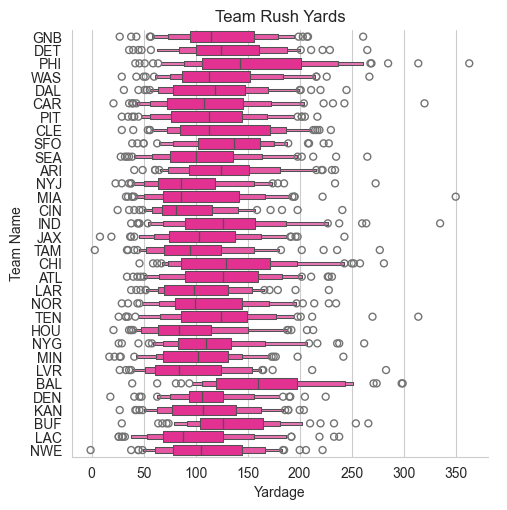

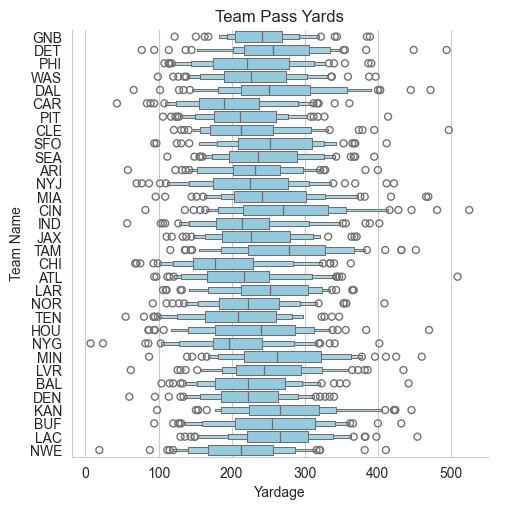

In [9]:
#Rushing & Passing Yards by Team
sns.set_style('whitegrid')
bx_plot1 = sns.catplot(y=stats_team['team_name'], x=stats_team['rushyards'], color='deeppink', kind='boxen')
bx_plot1.set_axis_labels('Yardage', 'Team Name')
bx_plot1.set_titles('Team Rush Yards')
plt.title('Team Rush Yards')

bx_plot2 = sns.catplot(y=stats_team['team_name'], x=stats_team['yards'], color='skyblue', kind='boxen')
bx_plot2.set_axis_labels('Yardage', 'Team Name')
bx_plot2.set_titles('Team Pass Yards')
plt.title('Team Pass Yards')

## Histograms

### Team Statistics

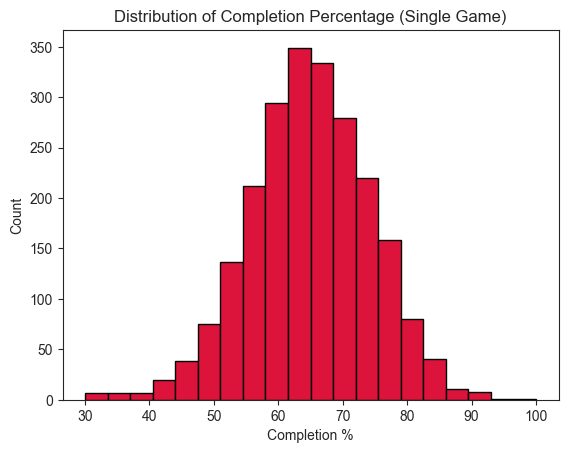

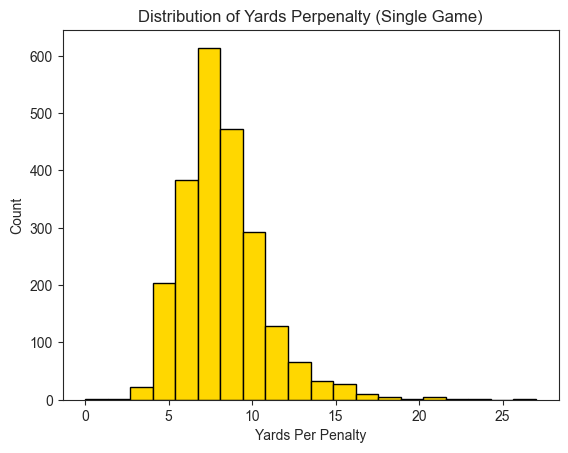

In [10]:
sns.set_style('ticks')
#Completion Percentage
plt.hist(x=stats_team.completionpct, edgecolor='black', color='crimson', bins=20)
plt.title('Distribution of Completion Percentage (Single Game)')
plt.xlabel('Completion %')
plt.ylabel('Count')
plt.show()

#Yards Per Penalty
plt.hist(x=stats_team.yards_per_penalty, edgecolor='black', color='gold', bins=20)
plt.title('Distribution of Yards Perpenalty (Single Game)')
plt.xlabel('Yards Per Penalty')
plt.ylabel('Count')
plt.show()

### Rushing Statistics

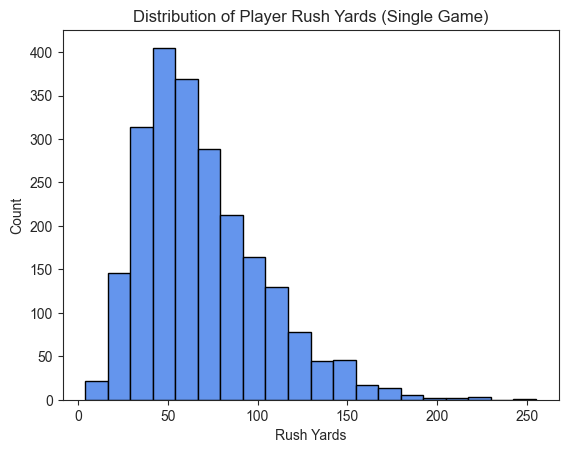

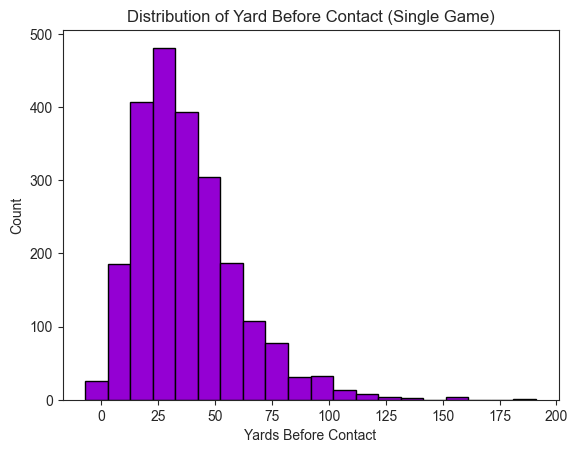

In [11]:
#Rush Yards
plt.hist(x=stats_rush.rushyards, edgecolor='black', color='cornflowerblue', bins=20)
plt.title('Distribution of Player Rush Yards (Single Game)')
plt.xlabel('Rush Yards')
plt.ylabel('Count')
plt.show()

#Rushing Yards Before Contact
plt.hist(x=stats_rush.yardsbeforecontact, edgecolor='black', color='darkviolet', bins=20)
plt.title('Distribution of Yard Before Contact (Single Game)')
plt.xlabel('Yards Before Contact')
plt.ylabel('Count')
plt.show()

### Passing Statistics

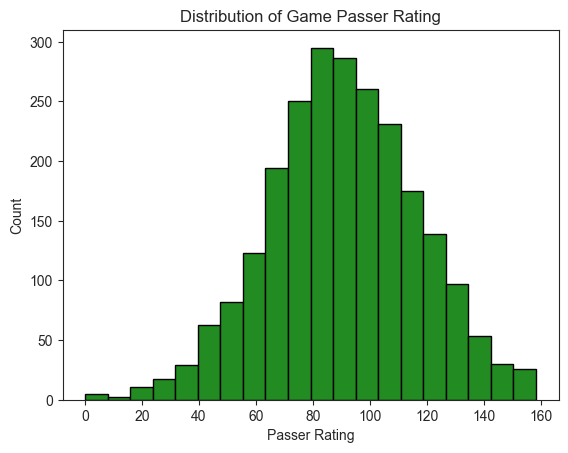

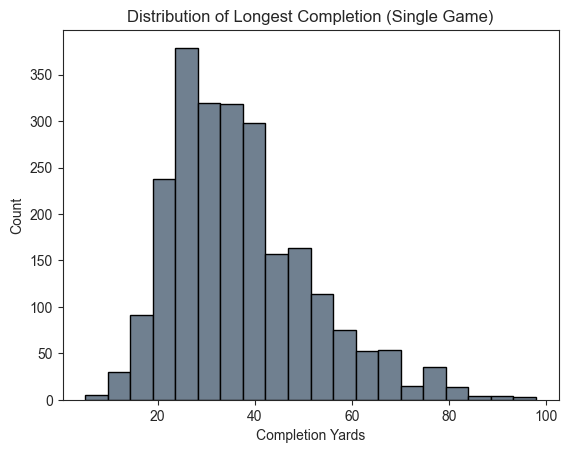

In [12]:
#Passer Rating
plt.hist(x=stats_pass.passrating, edgecolor='black', color='forestgreen', bins=20)
plt.title('Distribution of Game Passer Rating')
plt.xlabel('Passer Rating')
plt.ylabel('Count')
plt.show()

#Longest Completion
plt.hist(x=stats_pass.longestcompletion, edgecolor='black', color='slategrey', bins=20)
plt.title('Distribution of Longest Completion (Single Game)')
plt.xlabel('Completion Yards')
plt.ylabel('Count')
plt.show()

## Scatterplots

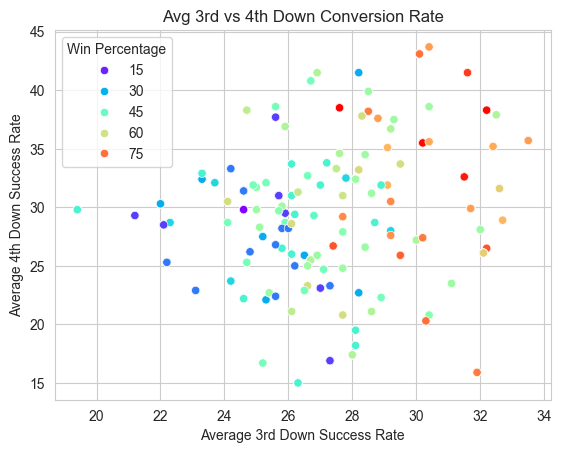

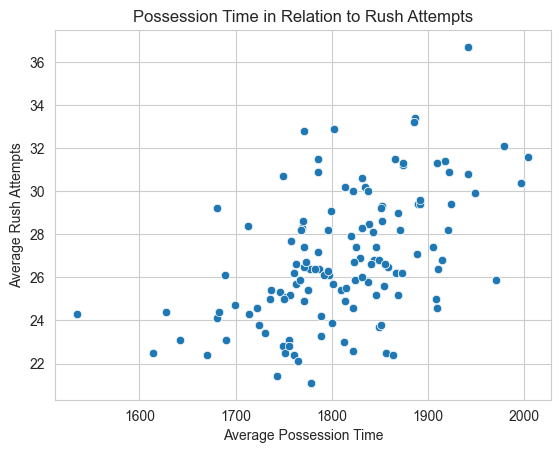

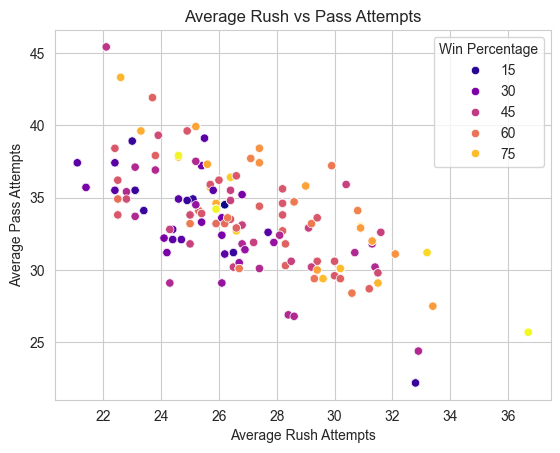

In [14]:
sns.set_style('whitegrid')
# Average 3rd vs 4th Down Conversion Rate
sc_plot1 = sns.scatterplot(data=stats_team,
                        x='successrate3rddown_avg',
                        y='successrate4thdown_avg',
                        hue='win_pct',
                        palette='rainbow')
sc_plot1.set_xlabel('Average 3rd Down Success Rate')
sc_plot1.set_ylabel('Average 4th Down Success Rate')
sc_plot1.set_title('Avg 3rd vs 4th Down Conversion Rate')
plt.legend(title='Win Percentage')
plt.show()

# Average Possession Time vs Rush Attempts
sc_plot2 = sns.scatterplot(data=stats_team,
                           x='possessiontime_avg',
                           y='rushattempts_avg')
sc_plot2.set_xlabel('Average Possession Time')
sc_plot2.set_ylabel('Average Rush Attempts')
sc_plot2.set_title('Possession Time in Relation to Rush Attempts')
plt.show()

#Average Rush vs Pass Attempts
sc_plot3 = sns.scatterplot(data=stats_team,
                           x='rushattempts_avg',
                           y='attempts_avg',
                           hue='win_pct',
                           palette='plasma')
sc_plot3.set_xlabel('Average Rush Attempts')
sc_plot3.set_ylabel('Average Pass Attempts')
sc_plot3.set_title('Average Rush vs Pass Attempts')
plt.legend(title='Win Percentage')
plt.show()

## Advanced Plots

### 3rd Down Success Rate in Wins and Losses

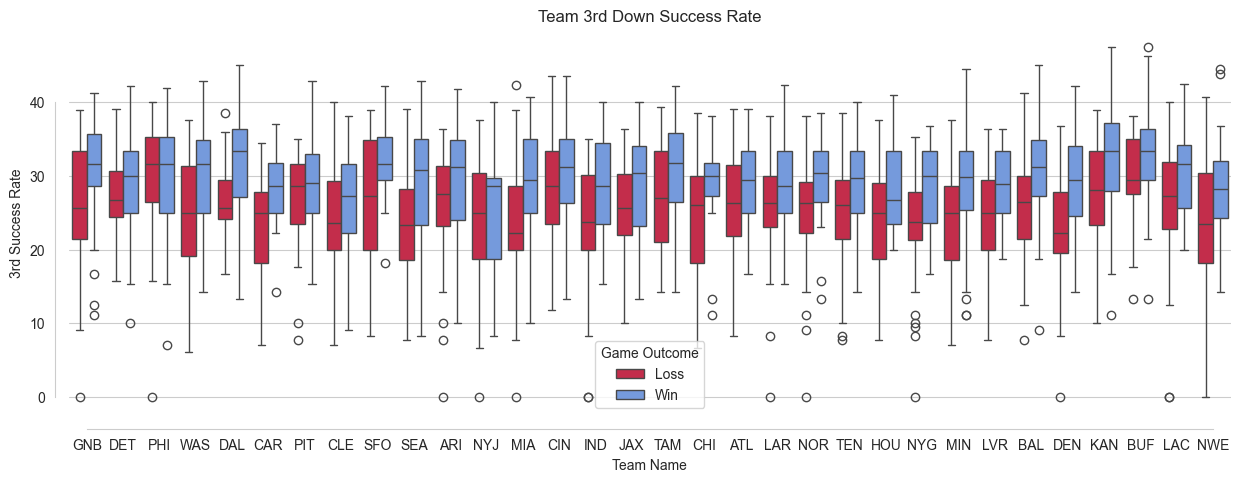

In [15]:
plt.figure(figsize=(15, 5))
sns.boxplot(data=stats_team, x='team_name', y='successrate3rddown', 
            hue='outcome2', palette=['crimson', 'cornflowerblue'])
sns.despine(offset=10, trim=True)
plt.xlabel('Team Name')
plt.ylabel('3rd Success Rate')
plt.title('Team 3rd Down Success Rate')
plt.legend(title='Game Outcome')
plt.show()

sns.reset_defaults()

### Hexbin of Completion % vs. Passing Attempts (w/ Single Variable Distribution on Axises)

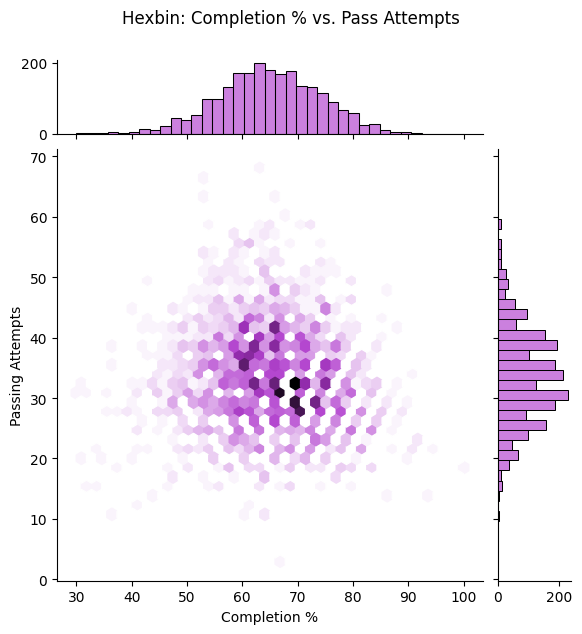

In [16]:
advplot1 = sns.jointplot(data=stats_team, x='completionpct', y='attempts',
              kind='hex', color='mediumorchid', marginal_ticks=True)
advplot1.figure.suptitle('Hexbin: Completion % vs. Pass Attempts', y=1.05)
advplot1.set_axis_labels(xlabel='Completion %', ylabel='Passing Attempts')
plt.show()

### Scatterplot of Yards Before vs. After Contact (w/ Linear Regression Line)

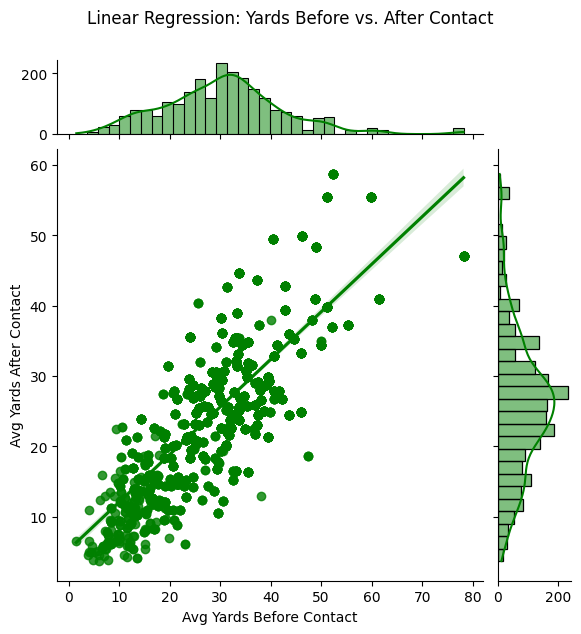

In [17]:
# Avg Yards Before vs. Yards After Contact
advplot2 = sns.jointplot(data=stats_rush, x='yardsbeforecontact_sn_avg',
                         y='yardsaftercontact_sn_avg', kind='reg', color='green', 
                         marginal_ticks=True)
advplot2.figure.suptitle('Linear Regression: Yards Before vs. After Contact', y=1.05)
advplot2.set_axis_labels(xlabel='Avg Yards Before Contact', ylabel='Avg Yards After Contact')
plt.show()

## Predictive Modeling

### Scikit-Learn

#### Linear Regression

In [18]:
x = stats_team[['possessiontime']]
m = LinearRegression().fit(x, stats_team.rushyards)
print(f'The intercept of the model is {m.intercept_}')
print(f'The estimated coefficient of the parameter is {m.coef_}')
print(f'The R-Squared value of the model is {round(m.score(x, stats_team.rushyards), 3)}')

The intercept of the model is -40.58627088881211
The estimated coefficient of the parameter is [0.08707091]
The R-Squared value of the model is 0.212


#### Logistic Regression

In [24]:
stats_team['outcome'] = stats_team['outcome'].astype('float')

x = stats_team[['successrate3rddown']]
y = stats_team.outcome
test_model = m.fit(x, y)
print(f'The intercept of the model is {test_model.intercept_}')
print(f'The estimated coefficient of the parameters are {test_model.coef_}')
print(f'The predicted accuracy of the model is {round(test_model.score(x, y), 3)}')

The intercept of the model is -0.05112806948169224
The estimated coefficient of the parameters are [0.02008232]
The predicted accuracy of the model is 0.094
